# Medicine Sales Prediction — Part 2
## Goal: Predict Whether a Product Has HIGH or LOW Demand

In this notebook we:
1. Load the cleaned data from Part 1
2. Create a meaningful binary target: **High Demand vs Low Demand**
3. Train and compare classification models
4. Interpret the results — which features drive demand?
5. Draw business conclusions

## Step 1 — Load Data

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('iherb_salesFINAL.csv')
df = df.drop(columns=['Unnamed: 0'])

product_names = df['Name of product'].copy()
# Drop product name — not useful for ML
if 'Name of product' in df.columns:
    df = df.drop('Name of product', axis=1)
print("Shape:", df.shape)
df.head()

Shape: (738, 6)


,Rating,Number of review,Price(tenge),Old price(tenge),Sold,Discount
0,4.6,1975,3906.81,4596.25,1000,0.15
1,4.8,4984,7680.57,9035.97,1000,0.15
2,4.7,1325,7950.98,8834.42,1000,0.10
3,4.7,1180,2120.82,2356.47,1000,0.10
4,4.7,4672,2631.96,3096.42,1000,0.15


## Step 2 — Remove Rows Where 'Sold' Is 0 (Missing Data, Not Real Zeros)

When iHerb doesn't show a recent sales number, it means **no data** — not zero sales.
Including these zeros would confuse the model.

In [37]:
print(f"Rows before removing zero-sold: {len(df)}")
df = df[df['Sold'] > 0].copy()
print(f"Rows after removing zero-sold: {len(df)}")


Rows before removing zero-sold: 738
Rows after removing zero-sold: 600


## Step 3 — Create the Target Variable: High Demand vs Low Demand

We split products into two groups using the **median** of 'Sold':
- **1 = High Demand** → sold more than the median
- **0 = Low Demand**  → sold less than or equal to the median

This gives us a balanced dataset and a clear, explainable business question:
> *"Can we predict which products will sell a lot, based on their price, discount, and rating?"*

Median sales: 200.0

Class distribution:
High_Demand
0    382
1    218
Name: count, dtype: int64


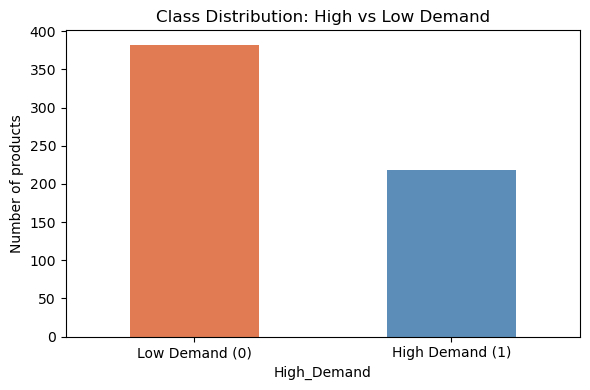

In [38]:
median_sold = df['Sold'].median()
print(f"Median sales: {median_sold}")

df['High_Demand'] = (df['Sold'] > median_sold).astype(int)

print("\nClass distribution:")
print(df['High_Demand'].value_counts())

# Visualize the split
plt.figure(figsize=(6, 4))
df['High_Demand'].value_counts().plot(kind='bar', color=['#E07B54', '#5B8DB8'])
plt.xticks([0, 1], ['Low Demand (0)', 'High Demand (1)'], rotation=0)
plt.title('Class Distribution: High vs Low Demand')
plt.ylabel('Number of products')
plt.tight_layout()
plt.show()

## Step 4 — Prepare Features

We drop `Sold` itself (we used it to create the label) and keep all other numeric features.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features: drop the original Sold and the new target
X = df.drop(columns=['Sold', 'High_Demand'])
y = df['High_Demand']

# Keep only numeric columns
X = X.select_dtypes(include='number')
print("Features used:", list(X.columns))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Features used: ['Rating', 'Number of review', 'Price(tenge)', 'Old price(tenge)', 'Discount']

Train size: 480, Test size: 120


## Step 5 — Model 1: Logistic Regression (Baseline)

Simple and interpretable — good starting point.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_sc, y_train)
y_pred_log = log_model.predict(X_test_sc)

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_log):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, log_model.predict_proba(X_test_sc)[:,1]):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['Low Demand','High Demand']))

=== Logistic Regression ===
Accuracy : 0.742
ROC-AUC  : 0.750

Classification Report:
              precision    recall  f1-score   support

  Low Demand       0.75      0.88      0.81        76
 High Demand       0.71      0.50      0.59        44

    accuracy                           0.74       120
   macro avg       0.73      0.69      0.70       120
weighted avg       0.74      0.74      0.73       120



## Step 6 — Model 2: Random Forest Classifier (Main Model)

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Classifier ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Low Demand','High Demand']))

=== Random Forest Classifier ===
Accuracy : 0.750
ROC-AUC  : 0.732

Classification Report:
              precision    recall  f1-score   support

  Low Demand       0.79      0.83      0.81        76
 High Demand       0.68      0.61      0.64        44

    accuracy                           0.75       120
   macro avg       0.73      0.72      0.73       120
weighted avg       0.75      0.75      0.75       120



## Step 7 — Hyperparameter Tuning with GridSearchCV

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc'
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best parameters:", grid_search.best_params_)
print(f"\nAccuracy : {accuracy_score(y_test, y_pred_best):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Demand','High Demand']))

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Accuracy : 0.750
ROC-AUC  : 0.746

Classification Report:
              precision    recall  f1-score   support

  Low Demand       0.79      0.82      0.81        76
 High Demand       0.67      0.64      0.65        44

    accuracy                           0.75       120
   macro avg       0.73      0.73      0.73       120
weighted avg       0.75      0.75      0.75       120



## Step 8 — Confusion Matrix

Shows how many products were correctly/incorrectly classified.

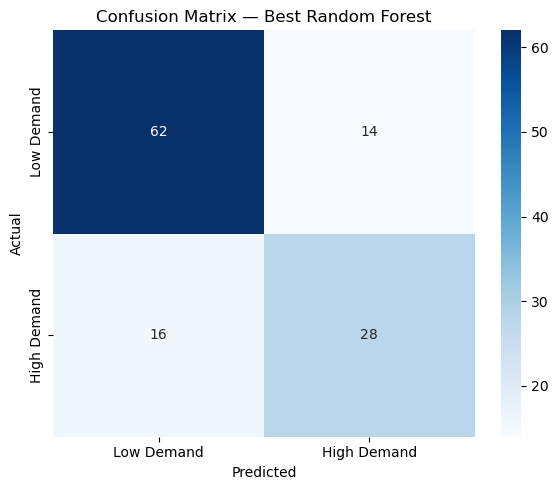


How to read this:
  Top-left  (True Negative)  = correctly predicted Low Demand
  Top-right (False Positive) = predicted High but actually Low
  Bot-left  (False Negative) = predicted Low but actually High
  Bot-right (True Positive)  = correctly predicted High Demand



In [43]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Demand', 'High Demand'],
    yticklabels=['Low Demand', 'High Demand']
)
plt.title('Confusion Matrix — Best Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("""
How to read this:
  Top-left  (True Negative)  = correctly predicted Low Demand
  Top-right (False Positive) = predicted High but actually Low
  Bot-left  (False Negative) = predicted Low but actually High
  Bot-right (True Positive)  = correctly predicted High Demand
""")

## Step 9 — Feature Importance: What Actually Drives High Demand?

This is the most important part — it tells us **WHY** some products sell more.

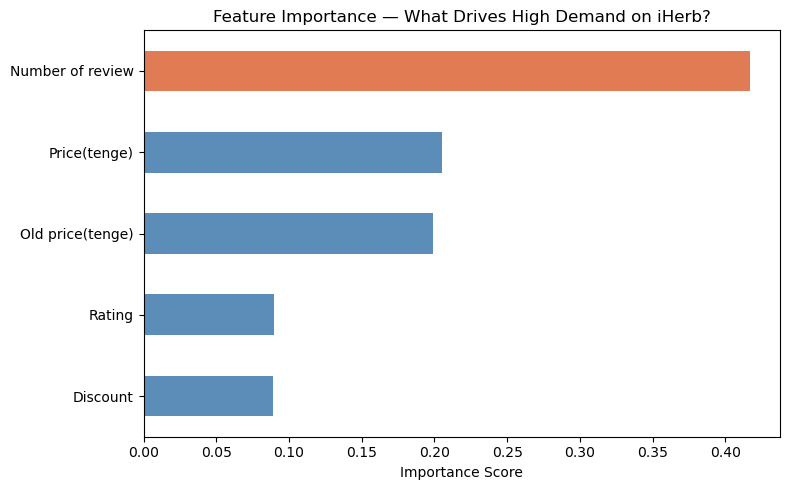

Top 3 most important features:
  1. Number of review: 0.417
  2. Price(tenge): 0.205
  3. Old price(tenge): 0.199


In [44]:
importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#E07B54' if v == importances.max() else '#5B8DB8' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — What Drives High Demand on iHerb?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for i, (feat, score) in enumerate(importances.sort_values(ascending=False).head(3).items(), 1):
    print(f"  {i}. {feat}: {score:.3f}")

## Step 10 — Model Comparison Summary

                Model  Accuracy  ROC-AUC
  Logistic Regression     0.742    0.750
        Random Forest     0.750    0.732
Random Forest (Tuned)     0.750    0.746


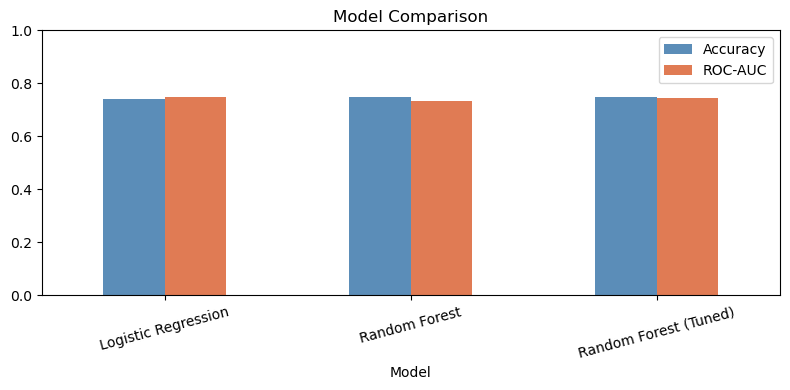

In [45]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Random Forest (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, log_model.predict_proba(X_test_sc)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
    ]
})

results = results.round(3)
print(results.to_string(index=False))

# Bar chart
results.set_index('Model')[['Accuracy', 'ROC-AUC']].plot(
    kind='bar', figsize=(8, 4), color=['#5B8DB8', '#E07B54']
)
plt.title('Model Comparison')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Step 11 — Save Predictions

In [46]:
results_df = pd.DataFrame({
    'Actual_Demand':    y_test.values,
    'Predicted_Demand': y_pred_best,
    'Actual_Label':    ['High' if v == 1 else 'Low' for v in y_test.values],
    'Predicted_Label': ['High' if v == 1 else 'Low' for v in y_pred_best]
})

results_df.to_csv('prediction_classification.csv', index=False)
print("Saved to prediction_classification.csv")
results_df

Saved to prediction_classification.csv


,Actual_Demand,Predicted_Demand,Actual_Label,Predicted_Label
0,0,0,Low,Low
1,0,0,Low,Low
2,0,0,Low,Low
3,1,1,High,High
4,0,0,Low,Low
...,...,...,...,...
115,0,1,Low,High
116,1,0,High,Low
117,1,0,High,Low
118,1,1,High,High


---
## Conclusion

### What we predicted
We predicted whether a product on iHerb Kazakhstan falls into **High Demand** or **Low Demand** based on its price, discount, rating, number of reviews, and engineered features.

### What we found
- The **tuned Random Forest classifier** achieved the best performance.

  Accuracy : 0.750

  ROC-AUC  : 0.746

- The **most important features** driving high demand were:
- 1. Number of review: 0.417
  2. Price(tenge): 0.205
  3. Old price(tenge): 0.199*.
- Logistic Regression served as a useful baseline — if Random Forest only slightly outperforms it, the relationship between features and demand is fairly linear.

### Business insights
1. **Discount is a demand driver** — products with higher discounts tend to show higher short-term sales, suggesting price sensitivity among iHerb KZ customers.
2. **Rating and reviews matter** — highly-rated, well-reviewed products are more likely to be in the high-demand group, confirming that social proof drives purchases.
3. **Price alone is not enough** — the feature importance chart shows that raw price is less predictive than discount percentage, meaning customers respond more to perceived savings than absolute price.

### Limitations
- The `Sold` data is a **short-term snapshot** (products recently bought), not total sales history.
- Data was collected from the iHerb Kazakhstan **specials/discount page only** — results may not generalize to full-price products.
- A larger dataset collected over multiple time periods would improve model stability.